In [18]:
from birdnet_analyzer.audio import open_audio_file, get_audio_file_length, get_sample_rate, save_signal, split_signal
from birdnet_analyzer.utils import collect_audio_files, list_subdirectories
import os

data = "D:/Acoustics/AnuraSET/raw_data/raw_data/"
for directory in list_subdirectories("D:/Acoustics/AnuraSET/raw_data/raw_data/"):
    print(directory)
    for audio_file in collect_audio_files(data+directory):
        signal, sample_rate = open_audio_file(audio_file) #Automatically resamples to 48kHz
        length = get_audio_file_length(audio_file)
        shards = split_signal(signal, sample_rate, 3.0, 2.0, 3.0)
        audio_file = os.path.basename(audio_file)
        audio_file = audio_file.replace(".wav", "_shard_")
        for i, shard in enumerate(shards, start=1):
            save_signal(shard, "D:\\Acoustics\\AnuraSet_3sec\\" + directory + "\\" + audio_file + str(i) + ".wav", sample_rate)



INCT17
['INCT17_20191113_040000.wav', 'INCT17_20191125_040000.wav', 'INCT17_20191126_040000.wav', 'INCT17_20191201_171500.wav', 'INCT17_20191205_004500.wav', 'INCT17_20191205_181500.wav', 'INCT17_20191205_191500.wav', 'INCT17_20191205_201500.wav', 'INCT17_20191205_211500.wav', 'INCT17_20191205_221500.wav', 'INCT17_20191205_231500.wav', 'INCT17_20191206_013000.wav', 'INCT17_20191206_174500.wav', 'INCT17_20191207_021500.wav', 'INCT17_20191207_031500.wav', 'INCT17_20191209_174500.wav', 'INCT17_20191215_184500.wav', 'INCT17_20191215_194500.wav', 'INCT17_20191215_204500.wav', 'INCT17_20191215_214500.wav', 'INCT17_20191215_224500.wav', 'INCT17_20191215_234500.wav', 'INCT17_20191216_001500.wav', 'INCT17_20191217_010000.wav', 'INCT17_20191217_024500.wav', 'INCT17_20191217_034500.wav', 'INCT17_20191217_183000.wav', 'INCT17_20191217_193000.wav', 'INCT17_20191217_203000.wav', 'INCT17_20191217_213000.wav', 'INCT17_20191217_223000.wav', 'INCT17_20191217_233000.wav', 'INCT17_20191218_000000.wav', 'I

KeyboardInterrupt: 

In [13]:
import audioutils

audioutils.upsample_wav("D:/Acoustics/AnuraSET/raw_data/raw_data/INCT4/INCT4_20191005_173000.wav", 
                        "D:/Acoustics/AnuraSet_3sec/INCT4_20191005_173000_upsampled.wav",
                        48000)

Unexpected error: Error opening 'D:/Acoustics/AnuraSet_3sec/INCT4/INCT4_20191005_173000_upsampled.wav': System error.


In [30]:
directory = r"D:\Acoustics\AnuraSET\strong_labels"
import os
import pandas as pd

expected_cols = ["start", "end", "species"]
dfs = []

for root, _, flist in os.walk(directory):
    for f in flist:
        if not f.endswith(".txt"):
            continue

        label_file_path = os.path.join(root, f)
        try:
            new_df = pd.read_csv(label_file_path, sep="\t", names=expected_cols)
        except pd.errors.EmptyDataError:
            continue
        except Exception:
            continue

        if new_df.empty:
            continue

        dfs.append(new_df)

if dfs:
    df = pd.concat(dfs, ignore_index=True)
else:
    df = pd.DataFrame(columns=expected_cols)

df

,start,end,species
0,0.000000,59.988753,PHYSAU_M
1,9.960731,10.344517,LEPFUS_M
2,13.113683,13.302624,PITAZU_L
3,15.422305,15.564011,PITAZU_L
4,17.140487,17.229053,PITAZU_L
...,...,...,...
15995,19.130272,20.405623,BOAALB_L
15996,26.215557,28.955201,BOAALB_L
15997,32.875726,36.040487,BOAALB_L
15998,38.307778,46.337769,BOAALB_L


In [31]:
df["length"] = df["end"] - df["start"]
df

,start,end,species,length
0,0.000000,59.988753,PHYSAU_M,59.988753
1,9.960731,10.344517,LEPFUS_M,0.383786
2,13.113683,13.302624,PITAZU_L,0.188941
3,15.422305,15.564011,PITAZU_L,0.141706
4,17.140487,17.229053,PITAZU_L,0.088566
...,...,...,...,...
15995,19.130272,20.405623,BOAALB_L,1.275351
15996,26.215557,28.955201,BOAALB_L,2.739644
15997,32.875726,36.040487,BOAALB_L,3.164761
15998,38.307778,46.337769,BOAALB_L,8.029991


start      2835
end        2835
species    2835
length     2835
dtype: int64

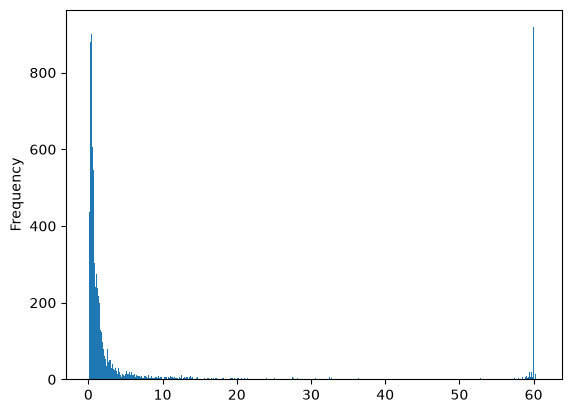

In [41]:
df["length"].plot.hist(bins=1000)
df["length"].describe()
df[df["length"] > 5].count()


In [5]:
import pandas as pd
species_path = "./specieslist.csv"

df = pd.read_csv(species_path, sep=";")
df = df.loc[df["display"] == 1]

# for species in list(df["scientific_name"]):
#     print(type(species))

df
#for species in df["scientific_name"]:

,scientific_name,display
24,Phyllobates vittatus,1.0
28,Boana rosenbergi,1.0
29,Dendropsophus ebraccatus,1.0
30,Dendropsophus microcephalus,1.0
31,Scinax boulengeri,1.0
39,Engystomops pustulosus,1.0
49,Agalychnis callidryas,1.0
50,Agalychnis spurrelli,1.0
